**Output Management**  
The figures and summary tables generated from this notebook are designed to be automatically saved in the `output/` folder.


# 1. Introduction & Dataset Overview

This notebook presents the implementation of supervised and unsupervised learning methods to predict the **Monthly_Spend** and understand **customer behaviour** in the context of streaming services.

**Dataset overview**
- File name: `Component 1 dataset_Streaming.csv`
- 5,000 customer records
- 12 columns:
  - `Customer_ID` – unique identifier, not used as a predictor
  - `Age` (float, 500 missing values)
  - `Gender` (categorical: Male / Female)
  - `Subscription_Length` (int, months)
  - `Region` (categorical, four categories e.g. North, South, East, West)
  - `Payment_Method` (categorical, three categories e.g. Credit Card, Debit Card, PayPal)
  - `Support_Tickets_Raised` (int)
  - `Satisfaction_Score` (float, 1–10, 500 missing values)
  - `Discount_Offered` (float)
  - `Last_Activity` (int, days since last interaction)
  - `Monthly_Spend` (float, **regression target**)
  - `Churned` (int: 0 = not churned, 1 = churned, mild class imbalance) – **classification target**.

The presentation is based on the structure of the brief (questions **(a)–(h)**) with clearly labelled sections in both the markdown and the code outputs.

In [1]:
# Create output directory where all generated outputs will be saved
import os
OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Outputs will be saved to the folder: {OUTPUT_DIR}')


Outputs will be saved to the folder: output


In [2]:
# 1.1 Import libraries and set global options
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    silhouette_score
)

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

import random

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


# Reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

sns.set(style='whitegrid')
%matplotlib inline


C:\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


=== 1.2 Load dataset and show basic information ===

Data shape (rows, columns): (5000, 12)

First 5 rows:


,Customer_ID,Age,Gender,Subscription_Length,Region,Payment_Method,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
0,CUST000001,56.0,Male,54,South,PayPal,0,9.0,6.42,319,62.11,1
1,CUST000002,69.0,Female,21,East,Debit Card,1,2.0,13.77,166,37.27,1
2,CUST000003,46.0,Female,49,East,PayPal,3,8.0,19.91,207,61.82,0
3,CUST000004,32.0,Male,47,West,Debit Card,3,1.0,13.39,108,40.96,1
4,CUST000005,60.0,Male,6,East,Credit Card,2,NaN,13.18,65,45.97,0



DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             5000 non-null   object 
 1   Age                     4500 non-null   float64
 2   Gender                  5000 non-null   object 
 3   Subscription_Length     5000 non-null   int64  
 4   Region                  5000 non-null   object 
 5   Payment_Method          5000 non-null   object 
 6   Support_Tickets_Raised  5000 non-null   int64  
 7   Satisfaction_Score      4500 non-null   float64
 8   Discount_Offered        5000 non-null   float64
 9   Last_Activity           5000 non-null   int64  
 10  Monthly_Spend           5000 non-null   float64
 11  Churned                 5000 non-null   int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB
None

Descriptive statistics for numeric variables:


,Age,Subscription_Length,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
count,4500.000000,5000.000000,5000.000000,4500.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.582222,29.704400,2.037000,5.54600,12.458404,181.441400,46.619784,0.448000
std,14.969559,17.050336,1.422405,2.86929,4.325381,104.500951,9.522140,0.497338
min,18.000000,1.000000,0.000000,1.00000,5.000000,1.000000,-5.060000,0.000000
25%,31.000000,15.000000,1.000000,3.00000,8.700000,90.000000,39.897500,0.000000
50%,43.000000,29.000000,2.000000,6.00000,12.500000,182.000000,46.625000,0.000000
75%,56.000000,44.000000,3.000000,8.00000,16.190000,271.000000,53.210000,1.000000
max,69.000000,59.000000,9.000000,10.00000,20.000000,364.000000,137.310000,1.000000



Missing values per column:


Customer_ID                 0
Age                       500
Gender                      0
Subscription_Length         0
Region                      0
Payment_Method              0
Support_Tickets_Raised      0
Satisfaction_Score        500
Discount_Offered            0
Last_Activity               0
Monthly_Spend               0
Churned                     0
dtype: int64


Churned distribution (counts):


Churned
0    2760
1    2240
Name: count, dtype: int64


Churned distribution (percentages):


Churned
0    55.2
1    44.8
Name: count, dtype: float64

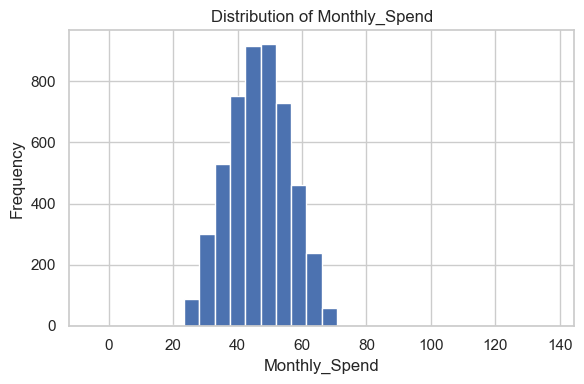

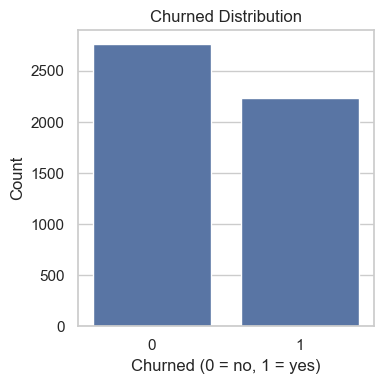

In [3]:
# 1.2 Load dataset and basic exploration
print('=== 1.2 Load dataset and show basic information ===')

file_path = 'Component 1 dataset_Streaming.csv'  #in the same directory as this notebook
df = pd.read_csv(file_path)

print('\nData shape (rows, columns):', df.shape)
print('\nFirst 5 rows:')
display(df.head())

print('\nDataFrame info:')
print(df.info())

print('\nDescriptive statistics for numeric variables:')
display(df.describe())

print('\nMissing values per column:')
display(df.isna().sum())

print('\nChurned distribution (counts):')
churn_counts = df['Churned'].value_counts().sort_index()
display(churn_counts)

print('\nChurned distribution (percentages):')
churn_percentages = churn_counts / len(df) * 100
display(churn_percentages)

# 1.3 Simple visualisations: Monthly_Spend and Churned
plt.figure(figsize=(6,4))
plt.hist(df['Monthly_Spend'].dropna(), bins=30)
plt.title('Distribution of Monthly_Spend')
plt.xlabel('Monthly_Spend')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'monthly_spend_hist.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(OUTPUT_DIR, 'churn_distribution_bar.png'), dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(4,4))
sns.countplot(x='Churned', data=df)
plt.title('Churned Distribution')
plt.xlabel('Churned (0 = no, 1 = yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'monthly_spend_hist.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(OUTPUT_DIR, 'churn_distribution_bar.png'), dpi=300, bbox_inches='tight')
plt.show()


# 2. Data Preprocessing (Shared Across All Tasks)

In this section I prepared the data for all subsequent regression, classification and clustering tasks:
- Dropped `Customer_ID` from all feature sets (not used as a predictor).
- Explicitly defined **numeric** and **categorical** features.
- Impute missing values in `Age` and `Satisfaction_Score` (and any other numeric columns if needed) using the median.
- Created reusable preprocessing pipelines for:
  - numeric-only regression tasks, and
  - mixed numeric + categorical tasks using a `ColumnTransformer`.
- Created a consistent **train–test split** for regression tasks so that the same rows are going to be used when comparing models.

In [4]:
# 2.1 Define feature groups and regression indices
print('=== 2.1 Define features and create consistent regression train/test indices ===')

numeric_features = ['Age', 'Subscription_Length', 'Support_Tickets_Raised',
                   'Satisfaction_Score', 'Discount_Offered', 'Last_Activity']
categorical_features = ['Gender', 'Region', 'Payment_Method']

# Targets
y_reg = df['Monthly_Spend']
y_clf = df['Churned']

# Create consistent regression indices (same rows for all regression models)
indices = np.arange(len(df))
reg_train_idx, reg_test_idx = train_test_split(indices, test_size=0.2, random_state=42)

print('Number of training samples (regression):', len(reg_train_idx))
print('Number of test samples (regression):', len(reg_test_idx))


=== 2.1 Define features and create consistent regression train/test indices ===
Number of training samples (regression): 4000
Number of test samples (regression): 1000


In [5]:
# 2.2 Create base feature sets for regression and classification
print('=== 2.2 Create base feature sets ===')

# Regression – numeric-only features
X_reg_numeric = df[numeric_features]

# Regression & classification – mixed numeric + categorical features
X_all_features = df.drop(columns=['Customer_ID', 'Monthly_Spend', 'Churned'])

# Classification feature set and stratified split
X_clf = X_all_features.copy()
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print('Number of training samples (classification):', X_clf_train.shape[0])
print('Number of test samples (classification):', X_clf_test.shape[0])

print('\nChurned distribution in training set:')
display(y_clf_train.value_counts(normalize=True).sort_index() * 100)


=== 2.2 Create base feature sets ===
Number of training samples (classification): 4000
Number of test samples (classification): 1000

Churned distribution in training set:


Churned
0    55.2
1    44.8
Name: proportion, dtype: float64

In [6]:
# 2.3 Define preprocessing pipelines
print('=== 2.3 Define preprocessing pipelines ===')

# Numeric-only preprocessing (for regression with numeric predictors only)
numeric_only_preprocessor = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

# Mixed numeric + categorical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot',  __import__('sklearn').preprocessing._encoders.OneHotEncoder if False else None)
    ]
)

# Because of version differences in scikit-learn, we define OneHotEncoder separately to ensure dense output.
from sklearn.preprocessing import OneHotEncoder

# Updated for newer sklearn versions
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
)

mixed_preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Containers to collect results for later comparison
regression_results = []
classification_results = []


=== 2.3 Define preprocessing pipelines ===


# 3. Q(a) – Single-Feature Regression Models

For each numerical feature individually (`Age`, `Subscription_Length`, `Support_Tickets_Raised`, `Satisfaction_Score`, `Discount_Offered`, `Last_Activity`), I fitted:
- a **linear regression** model; and
- a **polynomial regression** model (degree 2).

I then evaluated each of the model using **R²** and **RMSE** on the **same regression train–test split** and also summarised the best-performing model type for each of the feature.

In [7]:
# 3.1 Train and evaluate single-feature regression models (linear vs polynomial)
print('=== 3.1 Single-feature regression models ===')

single_feature_results = []

for feature in numeric_features:
    print(f"\n--- Feature: {feature} ---")

    # Create consistent train/test splits for this feature
    X_feature = df[[feature]]
    X_train = X_feature.iloc[reg_train_idx]
    X_test = X_feature.iloc[reg_test_idx]
    y_train = y_reg.iloc[reg_train_idx]
    y_test = y_reg.iloc[reg_test_idx]

    # Linear regression pipeline
    linear_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ])

    linear_pipeline.fit(X_train, y_train)
    y_train_pred_lin = linear_pipeline.predict(X_train)
    y_test_pred_lin = linear_pipeline.predict(X_test)

    lin_r2_train = r2_score(y_train, y_train_pred_lin)
    lin_r2_test = r2_score(y_test, y_test_pred_lin)
    lin_rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred_lin))
    lin_rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_lin))

    # Polynomial (degree 2) regression pipeline
    poly_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ])

    poly_pipeline.fit(X_train, y_train)
    y_train_pred_poly = poly_pipeline.predict(X_train)
    y_test_pred_poly = poly_pipeline.predict(X_test)

    poly_r2_train = r2_score(y_train, y_train_pred_poly)
    poly_r2_test = r2_score(y_test, y_test_pred_poly)
    poly_rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred_poly))
    poly_rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_poly))

    # Choose best model type based on test RMSE
    if poly_rmse_test < lin_rmse_test:
        best_type = 'Polynomial (degree=2)'
        best_r2_test = poly_r2_test
        best_rmse_test = poly_rmse_test
    else:
        best_type = 'Linear'
        best_r2_test = lin_r2_test
        best_rmse_test = lin_rmse_test

    single_feature_results.append({
        'model_id': f'Single_{feature}',
        'model_type': best_type,
        'features': feature,
        'R2_test': best_r2_test,
        'RMSE_test': best_rmse_test,
        'notes': 'Single numerical feature regression'
    })

single_results_df = pd.DataFrame(single_feature_results)

print('\n=== 3.1 Results Summary for Single-Feature Regression (sorted by RMSE_test) ===')
display(single_results_df.sort_values('RMSE_test'))


=== 3.1 Single-feature regression models ===

--- Feature: Age ---

--- Feature: Subscription_Length ---

--- Feature: Support_Tickets_Raised ---

--- Feature: Satisfaction_Score ---

--- Feature: Discount_Offered ---

--- Feature: Last_Activity ---

=== 3.1 Results Summary for Single-Feature Regression (sorted by RMSE_test) ===


,model_id,model_type,features,R2_test,RMSE_test,notes
3,Single_Satisfaction_Score,Polynomial (degree=2),Satisfaction_Score,0.534518,6.486895,Single numerical feature regression
1,Single_Subscription_Length,Linear,Subscription_Length,0.282882,8.051573,Single numerical feature regression
4,Single_Discount_Offered,Polynomial (degree=2),Discount_Offered,0.044591,9.293517,Single numerical feature regression
2,Single_Support_Tickets_Raised,Linear,Support_Tickets_Raised,0.017760,9.423111,Single numerical feature regression
0,Single_Age,Polynomial (degree=2),Age,-0.000793,9.511691,Single numerical feature regression
5,Single_Last_Activity,Polynomial (degree=2),Last_Activity,-0.000924,9.512313,Single numerical feature regression


=== 3.2 Single-feature regression plots ===


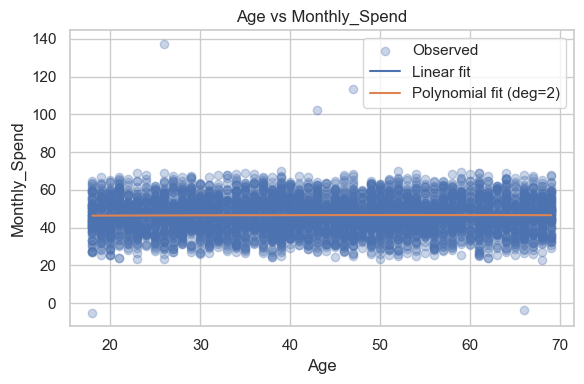

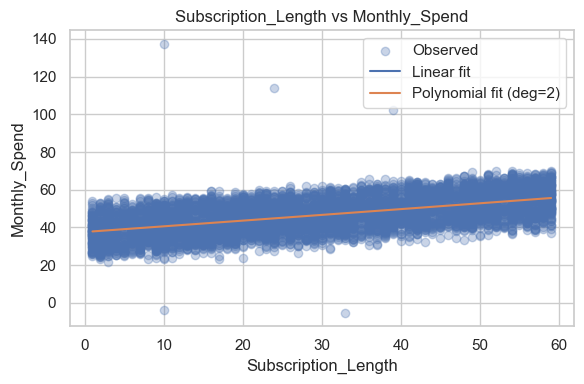

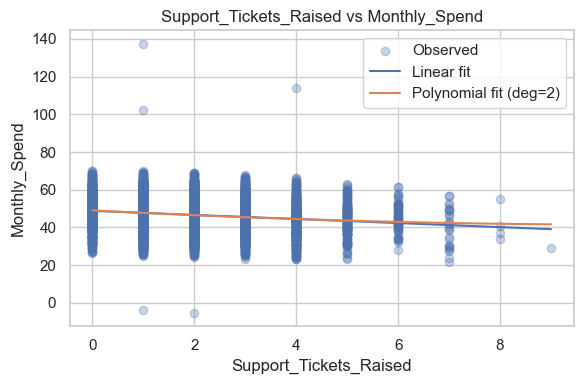

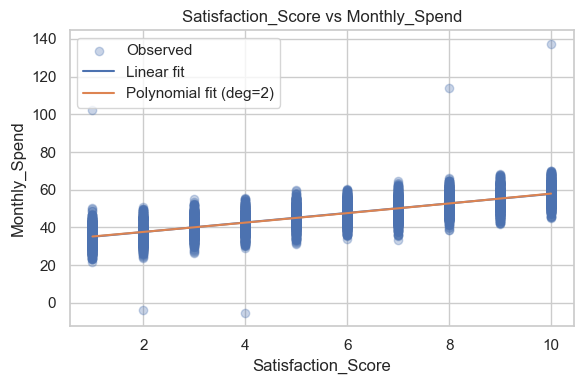

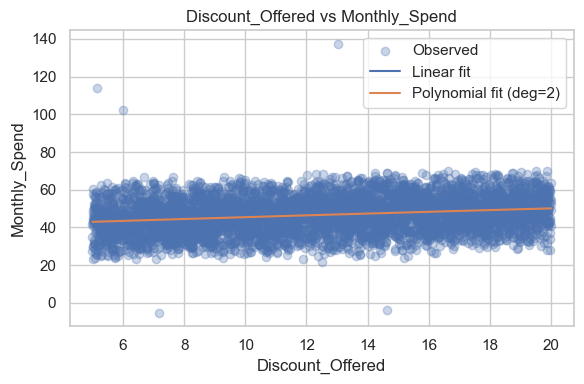

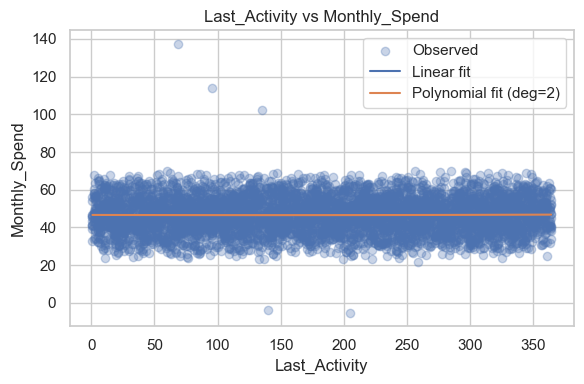

In [8]:
# 3.2 Visualise single-feature relationships with linear and polynomial fits
print('=== 3.2 Single-feature regression plots ===')

def plot_single_feature_regression(feature):
    subset = df[[feature, 'Monthly_Spend']].dropna()
    X = subset[[feature]]
    y = subset['Monthly_Spend']

    linear_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ])

    poly_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ])

    linear_pipeline.fit(X, y)
    poly_pipeline.fit(X, y)

    X_sorted = np.linspace(X[feature].min(), X[feature].max(), 100).reshape(-1, 1)
    y_pred_lin = linear_pipeline.predict(X_sorted)
    y_pred_poly = poly_pipeline.predict(X_sorted)

    plt.figure(figsize=(6, 4))
    plt.scatter(X[feature], y, alpha=0.3, label='Observed')
    plt.plot(X_sorted, y_pred_lin, label='Linear fit')
    plt.plot(X_sorted, y_pred_poly, label='Polynomial fit (deg=2)')
    plt.title(f'{feature} vs Monthly_Spend')
    plt.xlabel(feature)
    plt.ylabel('Monthly_Spend')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'single_feature_regression_plots.png'), dpi=300, bbox_inches='tight')
plt.show()

for feature in numeric_features:
    plot_single_feature_regression(feature)

# Extend global regression_results with single-feature models
regression_results.extend(single_feature_results)


# 4. Q(b) – Multiple Numerical Feature Regression

Here I built a regression model based on **all numerical predictors together** to predict `Monthly_Spend`:
- Predictors: `Age`, `Subscription_Length`, `Support_Tickets_Raised`, `Satisfaction_Score`, `Discount_Offered`, `Last_Activity`.
- Model: multiple linear regression with imputation + scaling.

I also compared the performance with the best single-feature model identified in Section 3.

In [9]:
# 4.1 Train and evaluate multi-feature numeric regression model
print('=== 4.1 Multiple numerical regression (Linear Regression) ===')

X_reg_num_train = X_reg_numeric.iloc[reg_train_idx]
X_reg_num_test = X_reg_numeric.iloc[reg_test_idx]
y_reg_train = y_reg.iloc[reg_train_idx]
y_reg_test = y_reg.iloc[reg_test_idx]

multi_numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

multi_numeric_pipeline.fit(X_reg_num_train, y_reg_train)
y_train_pred = multi_numeric_pipeline.predict(X_reg_num_train)
y_test_pred = multi_numeric_pipeline.predict(X_reg_num_test)

multi_r2_train = r2_score(y_reg_train, y_train_pred)
multi_r2_test = r2_score(y_reg_test, y_test_pred)

# RMSE computed manually (works on all sklearn versions)
multi_rmse_train = np.sqrt(mean_squared_error(y_reg_train, y_train_pred))
multi_rmse_test = np.sqrt(mean_squared_error(y_reg_test, y_test_pred))

print(f'R^2 (train): {multi_r2_train:.4f}')
print(f'R^2 (test):  {multi_r2_test:.4f}')
print(f'RMSE (train): {multi_rmse_train:.4f}')
print(f'RMSE (test):  {multi_rmse_test:.4f}')

# Compare with best single-feature model
best_single = min(single_feature_results, key=lambda x: x['RMSE_test'])
improvement = best_single['RMSE_test'] - multi_rmse_test

print('\nBest single-feature model:')
print(best_single)
print(f"\nImprovement in RMSE when using all numerical features: {improvement:.4f}")

regression_results.append({
    'model_id': 'MultiNumeric_Linear',
    'model_type': 'Multiple Linear Regression',
    'features': ', '.join(numeric_features),
    'R2_test': multi_r2_test,
    'RMSE_test': multi_rmse_test,
    'notes': 'All numerical predictors with imputation + scaling'
})


=== 4.1 Multiple numerical regression (Linear Regression) ===
R^2 (train): 0.8902
R^2 (test):  0.8861
RMSE (train): 3.1551
RMSE (test):  3.2085

Best single-feature model:
{'model_id': 'Single_Satisfaction_Score', 'model_type': 'Polynomial (degree=2)', 'features': 'Satisfaction_Score', 'R2_test': 0.5345182287057351, 'RMSE_test': np.float64(6.486895151974057), 'notes': 'Single numerical feature regression'}

Improvement in RMSE when using all numerical features: 3.2784


# 5. Q(c) – Regression with Numerical + Categorical Features

I have now included both numerical and categorical predictors to model `Monthly_Spend`:
- Numeric features: `Age`, `Subscription_Length`, `Support_Tickets_Raised`, `Satisfaction_Score`, `Discount_Offered`, `Last_Activity`.
- Categorical features: `Gender`, `Region`, `Payment_Method`.

Preprocessing uses a `ColumnTransformer`:
- numeric: median imputation + scaling
- categorical: most-frequent imputation + one-hot encoding

The regression model is a **RandomForestRegressor** used to capture non-linear relationships and interactions.

=== 5.1 Mixed-feature regression (Random Forest) ===
R^2 (train): 0.9809
R^2 (test):  0.8672
RMSE (train): 1.3164
RMSE (test):  3.4652

=== 5.2 Feature importance for Random Forest regression ===


,feature,importance
3,Satisfaction_Score,0.513631
1,Subscription_Length,0.312451
4,Discount_Offered,0.078651
2,Support_Tickets_Raised,0.034786
0,Age,0.021556
5,Last_Activity,0.020723
10,Region_South,0.002473
12,Payment_Method_Credit Card,0.002337
13,Payment_Method_Debit Card,0.002310
8,Region_East,0.002200


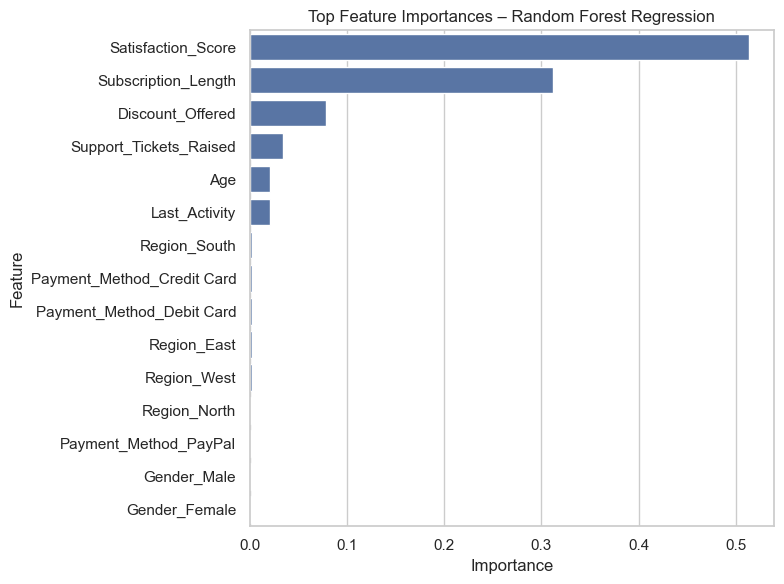

In [10]:
# 5.1 Train and evaluate RandomForestRegressor with numeric + categorical features
print('=== 5.1 Mixed-feature regression (Random Forest) ===')

X_reg_mixed = df.drop(columns=['Customer_ID', 'Monthly_Spend', 'Churned'])
X_reg_mixed_train = X_reg_mixed.iloc[reg_train_idx]
X_reg_mixed_test = X_reg_mixed.iloc[reg_test_idx]

mixed_preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

rf_regressor = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline([
    ('preprocessor', mixed_preprocessor_reg),
    ('regressor', rf_regressor)
])

rf_pipeline.fit(X_reg_mixed_train, y_reg_train)
y_train_pred_rf = rf_pipeline.predict(X_reg_mixed_train)
y_test_pred_rf = rf_pipeline.predict(X_reg_mixed_test)

rf_r2_train = r2_score(y_reg_train, y_train_pred_rf)
rf_r2_test = r2_score(y_reg_test, y_test_pred_rf)

# RMSE computed manually
rf_rmse_train = np.sqrt(mean_squared_error(y_reg_train, y_train_pred_rf))
rf_rmse_test = np.sqrt(mean_squared_error(y_reg_test, y_test_pred_rf))

print(f'R^2 (train): {rf_r2_train:.4f}')
print(f'R^2 (test):  {rf_r2_test:.4f}')
print(f'RMSE (train): {rf_rmse_train:.4f}')
print(f'RMSE (test):  {rf_rmse_test:.4f}')

regression_results.append({
    'model_id': 'Mixed_RF',
    'model_type': 'RandomForestRegressor',
    'features': 'All numerical + categorical',
    'R2_test': rf_r2_test,
    'RMSE_test': rf_rmse_test,
    'notes': 'Random forest with mixed features'
})

# 5.2 Feature importance (approximate) for Random Forest
print('\n=== 5.2 Feature importance for Random Forest regression ===')

# Extract feature names after preprocessing
preprocessor = rf_pipeline.named_steps['preprocessor']
num_features_out = numeric_features
cat_onehot = preprocessor.named_transformers_['cat']['onehot']
cat_features_out = list(cat_onehot.get_feature_names_out(categorical_features))
all_feature_names = num_features_out + cat_features_out

rf_model = rf_pipeline.named_steps['regressor']
importances = rf_model.feature_importances_
feature_importances_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

display(feature_importances_df.head(15))

plt.figure(figsize=(8,6))
top_n = 15
sns.barplot(x='importance', y='feature', data=feature_importances_df.head(top_n))
plt.title('Top Feature Importances – Random Forest Regression')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


# 6. Q(d) – ANN Regression for Monthly Spend

In this section I built an **Artificial Neural Network (ANN)** using TensorFlow/Keras to predict `Monthly_Spend` based on all of the numerical and categorical predictors.

Architecture:
- Input layer: matches the number of preprocessed features.
- Hidden layers: two dense layers with ReLU activation (64 and 32 neurons).
- Output layer: single neuron with linear activation (regression output).

Training setup:
- Loss: Mean Squared Error (MSE).
- Optimiser: Adam.
- Epochs: up to 100 with **early stopping** based on validation loss.
- Validation split: 20% of the training data.
- Batch size: 32.

=== 6.1 ANN regression with mixed features ===
Input dimension for ANN: 15


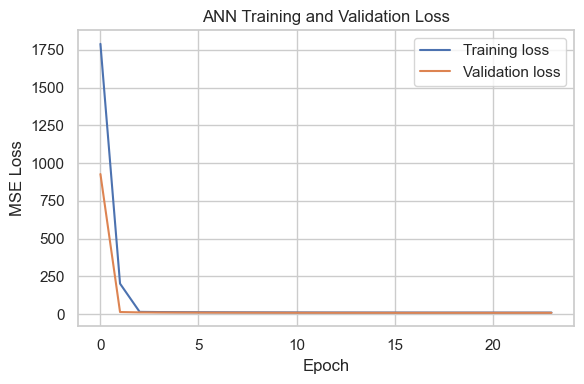

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
ANN R^2 (test): 0.8737
ANN RMSE (test): 3.3789


In [11]:
# 6.1 Preprocess data and train ANN
print('=== 6.1 ANN regression with mixed features ===')

# Reuse the same mixed feature set and regression indices
X_reg_mixed_train = X_reg_mixed.iloc[reg_train_idx]
X_reg_mixed_test = X_reg_mixed.iloc[reg_test_idx]
y_reg_train = y_reg.iloc[reg_train_idx]
y_reg_test = y_reg.iloc[reg_test_idx]

# Separate preprocessor for ANN to avoid interference with other pipelines
mixed_preprocessor_ann = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_train_pre = mixed_preprocessor_ann.fit_transform(X_reg_mixed_train)
X_test_pre = mixed_preprocessor_ann.transform(X_reg_mixed_test)

input_dim = X_train_pre.shape[1]
print('Input dimension for ANN:', input_dim)

# Build ANN model
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(input_dim,)),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

ann_model.compile(optimizer='adam', loss='mse')

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = ann_model.fit(
    X_train_pre, y_reg_train.values,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0
)

# Plot training and validation loss
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('ANN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Evaluate ANN on test set
y_test_pred_ann = ann_model.predict(X_test_pre).ravel()

ann_r2_test = r2_score(y_reg_test, y_test_pred_ann)
# RMSE computed manually (no squared=False)
ann_rmse_test = np.sqrt(mean_squared_error(y_reg_test, y_test_pred_ann))

print(f'ANN R^2 (test): {ann_r2_test:.4f}')
print(f'ANN RMSE (test): {ann_rmse_test:.4f}')

regression_results.append({
    'model_id': 'ANN_Mixed',
    'model_type': 'Artificial Neural Network',
    'features': 'All numerical + categorical',
    'R2_test': ann_r2_test,
    'RMSE_test': ann_rmse_test,
    'notes': 'Keras ANN with 2 hidden layers, early stopping'
})


# 7. Q(e) – Selecting the Best Model for Predicting Monthly Spend

I hereby compared all of the regression models that have been built so far:
- Best single-feature models (Section 3)
- Multiple numerical regression (Section 4)
- Mixed-feature Random Forest (Section 5)
- ANN regression (Section 6)

Comparison is based on **test RMSE** (primary) and **test R²** (secondary).

In [12]:
# 7.1 Regression model comparison table
print('=== 7.1 Regression model comparison ===')

regression_results_df = pd.DataFrame(regression_results)
display(regression_results_df.sort_values('RMSE_test'))

# Identify best model by RMSE on the test set
best_idx = regression_results_df['RMSE_test'].idxmin()
best_model_row = regression_results_df.loc[best_idx]

print('\nBest-performing regression model based on RMSE_test:')
print(best_model_row[['model_id', 'model_type', 'features', 'R2_test', 'RMSE_test', 'notes']])


=== 7.1 Regression model comparison ===


,model_id,model_type,features,R2_test,RMSE_test,notes
6,MultiNumeric_Linear,Multiple Linear Regression,"Age, Subscription_Length, Support_Tickets_Rais...",0.886124,3.208498,All numerical predictors with imputation + sca...
8,ANN_Mixed,Artificial Neural Network,All numerical + categorical,0.873704,3.378937,"Keras ANN with 2 hidden layers, early stopping"
7,Mixed_RF,RandomForestRegressor,All numerical + categorical,0.867176,3.465166,Random forest with mixed features
3,Single_Satisfaction_Score,Polynomial (degree=2),Satisfaction_Score,0.534518,6.486895,Single numerical feature regression
1,Single_Subscription_Length,Linear,Subscription_Length,0.282882,8.051573,Single numerical feature regression
4,Single_Discount_Offered,Polynomial (degree=2),Discount_Offered,0.044591,9.293517,Single numerical feature regression
2,Single_Support_Tickets_Raised,Linear,Support_Tickets_Raised,0.017760,9.423111,Single numerical feature regression
0,Single_Age,Polynomial (degree=2),Age,-0.000793,9.511691,Single numerical feature regression
5,Single_Last_Activity,Polynomial (degree=2),Last_Activity,-0.000924,9.512313,Single numerical feature regression



Best-performing regression model based on RMSE_test:
model_id                                    MultiNumeric_Linear
model_type                           Multiple Linear Regression
features      Age, Subscription_Length, Support_Tickets_Rais...
R2_test                                                0.886124
RMSE_test                                              3.208498
notes         All numerical predictors with imputation + sca...
Name: 6, dtype: object


# 8. Q(f) – Classification Models for Churn Prediction

Using `Churned` as the target, I hereby trained and compared the following three classifiers:
- Logistic Regression (with regularisation and class weights)
- Random Forest Classifier
- Support Vector Machine (RBF kernel)

Key points:
- Features: all numerical and categorical variables except `Customer_ID` and `Monthly_Spend`.
- Preprocessing: same mixed pipeline (numeric imputation + scaling, categorical imputation + one-hot encoding).
- Mild class imbalance (approx. 55.2% vs 44.8%) is handled using `class_weight='balanced'` where supported.
- Evaluation metrics: **Accuracy, Precision, Recall, F1-score, ROC-AUC**, plus confusion matrices and an ROC curve for the best model.

=== 8.1 Classification models for Churn prediction ===

Churned distribution (overall):


Churned
0    55.2
1    44.8
Name: proportion, dtype: float64

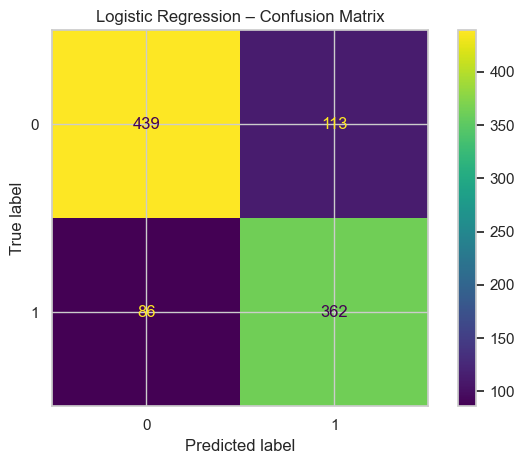

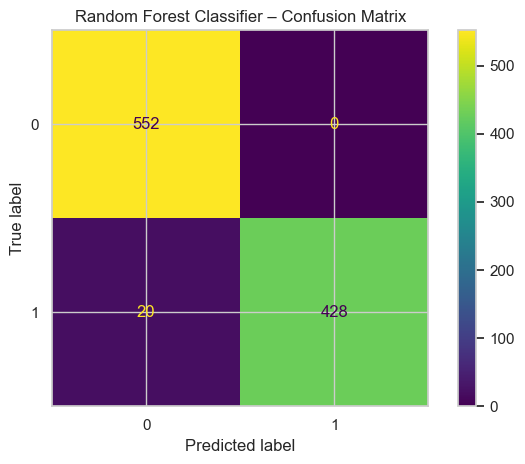

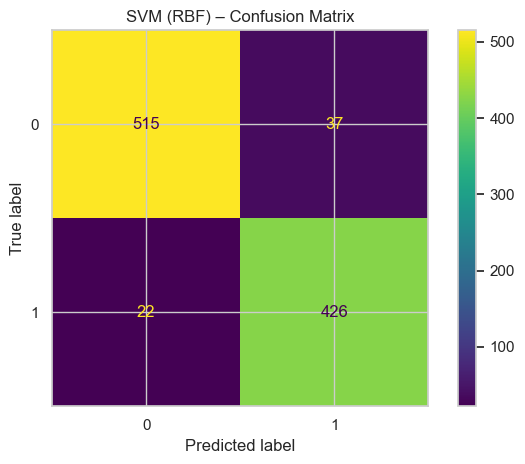

In [13]:
# 8.1 Helper function to build pipelines and evaluate classifiers
print('=== 8.1 Classification models for Churn prediction ===')

def make_classification_preprocessor():
    return ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ]
    )

def evaluate_classifier(model_name, classifier):
    """Fit classifier wrapped in a pipeline, compute metrics, plot confusion matrix, and return probabilities."""
    preprocessor = make_classification_preprocessor()
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])

    pipe.fit(X_clf_train, y_clf_train)
    y_pred = pipe.predict(X_clf_test)

    # Try to obtain probabilities for ROC-AUC
    clf_step = pipe.named_steps['classifier']
    if hasattr(clf_step, 'predict_proba'):
        y_proba = clf_step.predict_proba(pipe.named_steps['preprocessor'].transform(X_clf_test))[:, 1]
    else:
        scores = clf_step.decision_function(pipe.named_steps['preprocessor'].transform(X_clf_test))
        # Scale scores to [0,1]
        from sklearn.preprocessing import MinMaxScaler
        y_proba = MinMaxScaler().fit_transform(scores.reshape(-1, 1)).ravel()

    acc = accuracy_score(y_clf_test, y_pred)
    prec = precision_score(y_clf_test, y_pred)
    rec = recall_score(y_clf_test, y_pred)
    f1 = f1_score(y_clf_test, y_pred)
    roc = roc_auc_score(y_clf_test, y_proba)

    cm = confusion_matrix(y_clf_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(values_format='d')
    plt.title(f'{model_name} – Confusion Matrix')
    plt.tight_layout()
    plt.show()

    classification_results.append({
        'model_name': model_name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'roc_auc': roc
    })

    return y_proba, pipe

print('\nChurned distribution (overall):')
display(df['Churned'].value_counts(normalize=True).sort_index() * 100)

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1)
proba_log, pipe_log = evaluate_classifier('Logistic Regression', log_reg)

# Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', n_jobs=-1)
proba_rf, pipe_rf = evaluate_classifier('Random Forest Classifier', rf_clf)

# Support Vector Machine (RBF kernel)
svm_clf = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
proba_svm, pipe_svm = evaluate_classifier('SVM (RBF)', svm_clf)

# Collect probabilities for ROC plotting later
proba_by_model = {
    'Logistic Regression': proba_log,
    'Random Forest Classifier': proba_rf,
    'SVM (RBF)': proba_svm
}


=== 8.2 Classification model comparison ===


,model_name,accuracy,precision,recall,f1_score,roc_auc
1,Random Forest Classifier,0.980,1.000000,0.955357,0.977169,0.989365
2,SVM (RBF),0.941,0.920086,0.950893,0.935236,0.976716
0,Logistic Regression,0.801,0.762105,0.808036,0.784399,0.892894



Best-performing classifier based on ROC-AUC and F1-score:
model_name    Random Forest Classifier
accuracy                          0.98
precision                          1.0
recall                        0.955357
f1_score                      0.977169
roc_auc                       0.989365
Name: 1, dtype: object


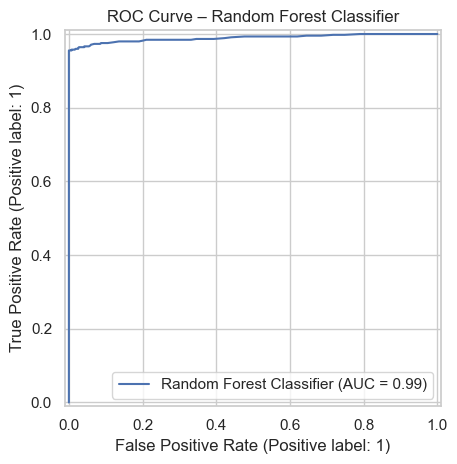

In [14]:
# 8.2 Classification metrics comparison and ROC curve for best model
print('=== 8.2 Classification model comparison ===')

classification_results_df = pd.DataFrame(classification_results)
display(classification_results_df.sort_values('roc_auc', ascending=False))

# Select best model primarily by ROC-AUC, then F1-score
best_clf_row = classification_results_df.sort_values(['roc_auc', 'f1_score'], ascending=False).iloc[0]
best_clf_name = best_clf_row['model_name']

print('\nBest-performing classifier based on ROC-AUC and F1-score:')
print(best_clf_row)

# Plot ROC curve for the best classifier
best_proba = proba_by_model[best_clf_name]
RocCurveDisplay.from_predictions(y_clf_test, best_proba, name=best_clf_name)
plt.title(f'ROC Curve – {best_clf_name}')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'best_model_roc_curve.png'), dpi=300, bbox_inches='tight')
plt.show()


# 9. Q(g) – k-Means Clustering

I hereby applied **k-Means clustering** to identify the natural groups of customers.

Clustering feature set:
- All numerical and categorical predictors **excluding** `Customer_ID`, `Monthly_Spend`, and `Churned`.

Steps:
1. Preprocess features (impute + scale numeric; impute + one-hot encode categorical).
2. Use the **elbow method** and **silhouette score** to choose an appropriate number of clusters `k`.
3. Fit k-Means with the chosen `k`.
4. Analyse cluster profiles in terms of average `Monthly_Spend`, `Satisfaction_Score`, and churn rate.
5. Visualise clusters in 2D using PCA.

=== 9.1 Elbow method and silhouette scores for k-Means ===


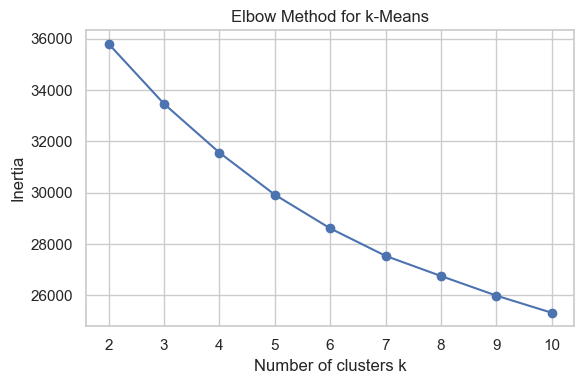

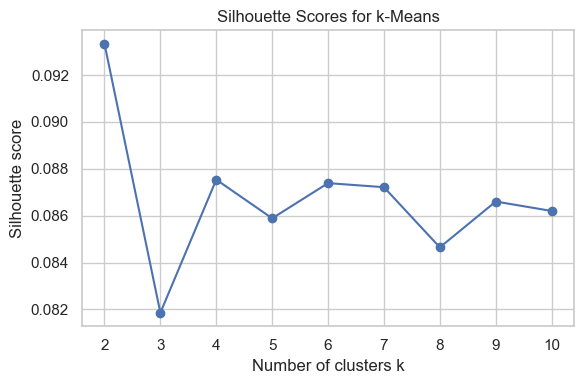

Chosen number of clusters (k) based on highest silhouette score: 2


In [15]:
# 9.1 Prepare data and determine optimal k using elbow and silhouette methods
print('=== 9.1 Elbow method and silhouette scores for k-Means ===')

cluster_features = df.drop(columns=['Customer_ID', 'Monthly_Spend', 'Churned'])

cluster_preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_cluster = cluster_preprocessor.fit_transform(cluster_features)

inertias = []
sil_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster)
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X_cluster, labels)
    sil_scores.append(sil)

# Plot inertia (elbow)
plt.figure(figsize=(6,4))
plt.plot(list(k_values), inertias, marker='o')
plt.xticks(list(k_values))
plt.xlabel('Number of clusters k')
plt.ylabel('Inertia')
plt.title('Elbow Method for k-Means')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'kmeans_elbow_plot.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(OUTPUT_DIR, 'kmeans_silhouette_plot.png'), dpi=300, bbox_inches='tight')
plt.show()

# Plot silhouette scores
plt.figure(figsize=(6,4))
plt.plot(list(k_values), sil_scores, marker='o')
plt.xticks(list(k_values))
plt.xlabel('Number of clusters k')
plt.ylabel('Silhouette score')
plt.title('Silhouette Scores for k-Means')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'kmeans_elbow_plot.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(OUTPUT_DIR, 'kmeans_silhouette_plot.png'), dpi=300, bbox_inches='tight')
plt.show()

best_k = k_values[np.argmax(sil_scores)]
print(f'Chosen number of clusters (k) based on highest silhouette score: {best_k}')


=== 9.2 Fit k-Means and analyse clusters ===

=== 9.3 Cluster Profiles (Average Spend, Satisfaction, Churn Rate, Age, Subscription_Length) ===


,Monthly_Spend,Satisfaction_Score,Churn_Rate,Age,Subscription_Length
Cluster,,,,,
0,48.543300,5.631184,0.455307,44.960374,29.719872
1,44.687013,5.459750,0.440658,42.208962,29.688853


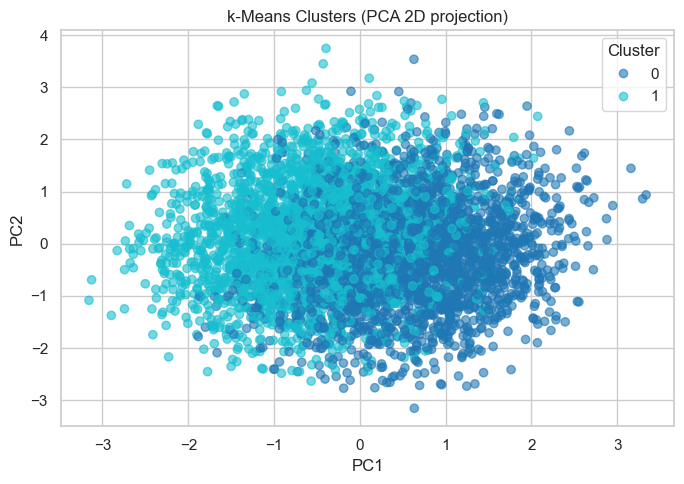

In [16]:
# 9.2 Fit k-Means with chosen k and analyse cluster profiles
print('=== 9.2 Fit k-Means and analyse clusters ===')

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_cluster)

df_clusters = df.copy()
df_clusters['Cluster'] = cluster_labels

cluster_summary = df_clusters.groupby('Cluster').agg({
    'Monthly_Spend': 'mean',
    'Satisfaction_Score': 'mean',
    'Churned': 'mean',
    'Age': 'mean',
    'Subscription_Length': 'mean'
}).rename(columns={'Churned': 'Churn_Rate'})

print('\n=== 9.3 Cluster Profiles (Average Spend, Satisfaction, Churn Rate, Age, Subscription_Length) ===')
display(cluster_summary)

# 9.4 Visualise clusters in 2D using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(7,5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('k-Means Clusters (PCA 2D projection)')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'kmeans_pca_clusters.png'), dpi=300, bbox_inches='tight')
plt.show()


# 10. Q(h) – Comparing k-Means with an Alternative Clustering Algorithm

As an alternative to k-Means, I applied **Agglomerative (hierarchical) clustering** on the same preprocessed feature set.

Steps:
- Fit `AgglomerativeClustering` with the same number of clusters `k` chosen earlier.
- Compute the silhouette score and compare with k-Means.
- Examine cluster size distribution.
- Plot a dendrogram on a random sample of 200 customers for interpretability.

I then commented on which of the algorithm provides a more meaningful segmentation of customer behaviour.

=== 10.1 Agglomerative clustering and comparison with k-Means ===
Silhouette score – k-Means: 0.0933
Silhouette score – Agglomerative: 0.0579

Cluster sizes (k-Means):


0    2506
1    2494
Name: count, dtype: int64


Cluster sizes (Agglomerative):


0    2293
1    2707
Name: count, dtype: int64


=== 10.2 Dendrogram for a sample of customers ===


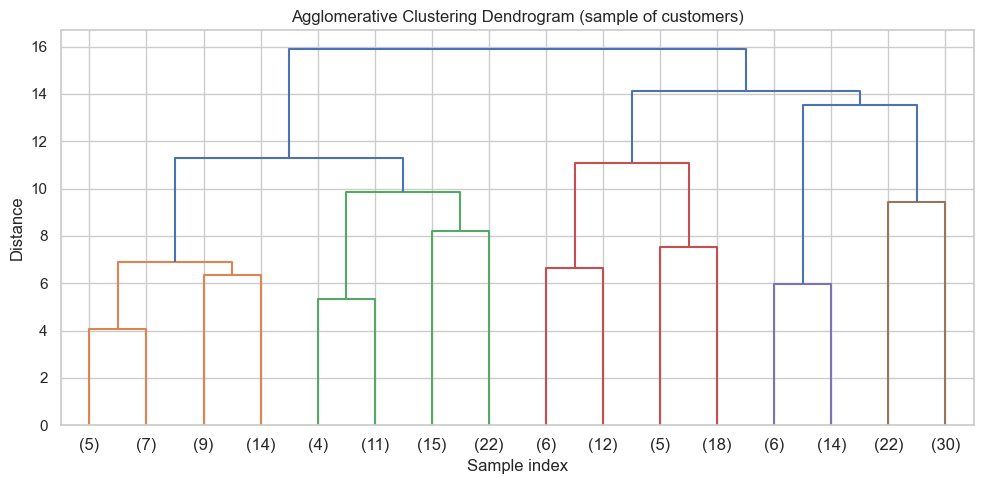

In [17]:
# 10.1 Fit AgglomerativeClustering and compare with k-Means
print('=== 10.1 Agglomerative clustering and comparison with k-Means ===')

agg_clustering = AgglomerativeClustering(n_clusters=best_k)
agg_labels = agg_clustering.fit_predict(X_cluster)

sil_kmeans = silhouette_score(X_cluster, cluster_labels)
sil_agg = silhouette_score(X_cluster, agg_labels)

print(f'Silhouette score – k-Means: {sil_kmeans:.4f}')
print(f'Silhouette score – Agglomerative: {sil_agg:.4f}')

# Cluster size distributions
print('\nCluster sizes (k-Means):')
display(pd.Series(cluster_labels).value_counts().sort_index())

print('\nCluster sizes (Agglomerative):')
display(pd.Series(agg_labels).value_counts().sort_index())

# 10.2 Dendrogram on a sample of 200 customers (for interpretability)
print('\n=== 10.2 Dendrogram for a sample of customers ===')

sample_size = min(200, X_cluster.shape[0])
sample_indices = np.random.choice(X_cluster.shape[0], size=sample_size, replace=False)
X_sample = X_cluster[sample_indices]

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='level', p=3)
plt.title('Agglomerative Clustering Dendrogram (sample of customers)')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


# 11. Final Summary and Next Steps

**Regression (Monthly_Spend prediction)**
- While Single-feature models show how each numerical variable individually relates to `Monthly_Spend`, Polynomial regression can capture simple non-linear patterns when they are present.

- The use of categorical variables (like `Gender`, `Region`, `Payment_Method`) and the use of a non-linear model such as Random Forest further is to help with predictive accuracy.

**Classification (Churn prediction)**
- All the classifiers handled the mild class imbalance using the `class_weight='balanced'`.


**Clustering (Customer segmentation)**
- The k-Means clustering on the fully preprocessed feature set is to reveal the groups of customers with distinct profiles in relation to the average `Monthly_Spend`, `Satisfaction_Score`, `Age`, `Subscription_Length`, and churn rate.



In [18]:
# Save key summary tables
regression_results_df.to_csv(os.path.join(OUTPUT_DIR, 'regression_model_comparison.csv'), index=False)
classification_results_df.to_csv(os.path.join(OUTPUT_DIR, 'classification_model_comparison.csv'), index=False)
cluster_summary.to_csv(os.path.join(OUTPUT_DIR, 'cluster_profiles.csv'))
print('Summary tables have been exported to the output folder.')


Summary tables have been exported to the output folder.


In [19]:
import os
notebook_name = "Component_1_Streaming_Analysis_Notebook_OutputReady.ipynb"
os.system(f'jupyter nbconvert --to html "{notebook_name}"')


0